<a href="https://colab.research.google.com/github/Diksha866/Autism_prediction/blob/master/Dog_vs_Cats_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dataset Information**
The trining archive contains 25,000 Images of dogs and cats . Train your algorithm on these files and predict the labels for test1.zip
(1= dog , 0= cat)

**Download Dataset**

In [2]:
!wget https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip

--2026-07-09 15:41:36--  https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.32.118.60, 2600:1408:c400:e93::317f, 2600:1408:c400:e89::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.32.118.60|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip.1’

kagglecatsanddogs_5 100%[===================>] 786.67M   137MB/s    in 10s     

2026-07-09 15:41:47 (75.7 MB/s) - ‘kagglecatsanddogs_5340.zip.1’ saved [824887076/824887076]



Unzip the Dataset

In [3]:
import os

zip_file_name = 'kagglecatsanddogs_5340.zip'

# Check if the zip file exists, if not, download it
if not os.path.exists(zip_file_name):
    print(f"'{zip_file_name}' not found. Re-downloading...")
    !wget https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip
    if not os.path.exists(zip_file_name):
        print(f"Error: Failed to download '{zip_file_name}'. Please check the URL or your connection.")
    else:
        print(f"'{zip_file_name}' downloaded successfully.")

# Unzip the dataset if the file exists
if os.path.exists(zip_file_name):
    print(f"Unzipping '{zip_file_name}'...")
    !unzip -q {zip_file_name}
    print("Dataset unzipped.")
else:
    print(f"Cannot unzip: '{zip_file_name}' is still missing.")

Unzipping 'kagglecatsanddogs_5340.zip'...
Dataset unzipped.


Import Modules

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import tqdm
import random
warnings.filterwarnings('ignore')
from keras. preprocessing.image import load_img

## Create DataFrame for Input and Output


In [5]:
input_path = []
label = []

for class_name in os.listdir("PetImages"):
  for path in os.listdir("PetImages/"+class_name):
    if class_name.lower() == 'cat':  # Make comparison case-insensitive
      label.append(0)
    else:
      label.append(1)
    input_path.append(os.path.join("PetImages", class_name, path))
print(input_path[0], label[0])

PetImages/Dog/9024.jpg 1


In [6]:
print(input_path[10], label[10])

PetImages/Dog/11360.jpg 1


In [7]:
df = pd.DataFrame()
df['images'] = input_path
df['label'] = label
# Convert label column to string type immediately after creation
df['label'] = df['label'].astype(str)
df = df.sample(frac = 1).reset_index(drop=True)
df.head()

,images,label
0,PetImages/Dog/6879.jpg,1
1,PetImages/Cat/1446.jpg,0
2,PetImages/Dog/9066.jpg,1
3,PetImages/Dog/908.jpg,1
4,PetImages/Cat/1798.jpg,0


**Exploratory Data Analysis**

In [8]:
# to display grid of images
plt.figure(figsize=(25,25))
temp = df[df['label']==1]['images']
start = random.randint(0, len(temp))
files = temp[start:start+25]

for index, file in enumerate(files):
  plt.subplot(5,5, index+1)
  img = load_img(file)
  img = np.array(img)
  plt.imshow(img)
  plt.title('Dogs')
  plt.axis('off')


<Figure size 2500x2500 with 0 Axes>

In [9]:
# to display grid of images
plt.figure(figsize=(25,25))
temp = df[df['label']==0]['images']
start = random.randint(0, len(temp))
files = temp[start:start+25]

for index, file in enumerate(files):
  plt.subplot(5,5, index+1)
  img = load_img(file)
  img = np.array(img)
  plt.imshow(img)
  plt.title('Cats')
  plt.axis('off')


<Figure size 2500x2500 with 0 Axes>

<Axes: xlabel='count', ylabel='label'>

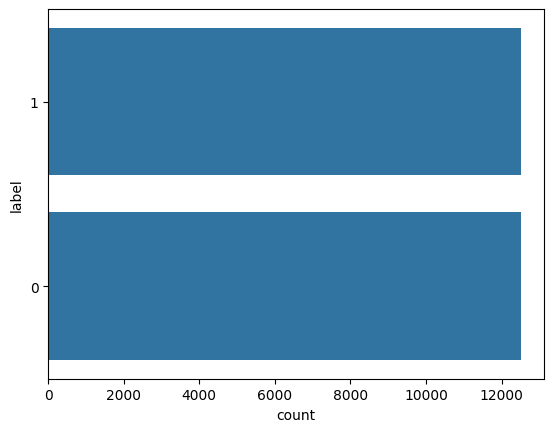

In [10]:
import seaborn as sns
sns.countplot(df['label'])

Create DataGenerator for the Images

In [11]:
from numpy.random import RandomState
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Split the DataFrame into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Convert labels to string type as required by flow_from_dataframe for binary classification
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)

# Training Data Generator
train_generator = ImageDataGenerator(
    rescale = 1./255, # normalization of images
    rotation_range = 40, # augmention of images to avoid overfitting
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode ='nearest'
)

# Validation Data Generator (only rescaling needed)
validation_generator = ImageDataGenerator(
    rescale=1./255
)

# Create train iterator
train_iterator = train_generator.flow_from_dataframe(
    train_df,
    x_col ='images',
    y_col='label',
    target_size = (120,120),
    batch_size = 65,
    class_mode = 'binary'
)

# Create validation iterator
validation_iterator = validation_generator.flow_from_dataframe(
    val_df,
    x_col ='images',
    y_col='label',
    target_size = (120,120),
    batch_size = 65,
    class_mode = 'binary',
    shuffle=False # No need to shuffle validation data
)

Found 19999 validated image filenames belonging to 2 classes.
Found 5001 validated image filenames belonging to 2 classes.


Model Creation


In [12]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(16, (3,3), activation = 'relu', input_shape = (120,120,3)),
    MaxPooling2D((2,2)),
    Conv2D(32, (3,3), activation = 'relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(512, activation = 'relu'),
    Dense(1, activation = 'sigmoid')
])

In [13]:
# The model compilation and summary have been moved to the model fitting cell to ensure they are executed together.

In [14]:
# The model compilation and training will be performed after data cleaning and re-creation of data generators to ensure consistency with the processed data.

In [15]:
import PIL

bad_images = []
for image_path in df['images']:
    try:
        PIL.Image.open(image_path)
    except PIL.UnidentifiedImageError:
        bad_images.append(image_path)

if bad_images:
    print(f"Found {len(bad_images)} bad images. Removing them from the DataFrame.")
    df = df[~df['images'].isin(bad_images)]
    df.reset_index(drop=True, inplace=True)
else:
    print("No bad images found.")

print("DataFrame after cleaning:")
display(df.head())

Found 4 bad images. Removing them from the DataFrame.
DataFrame after cleaning:


,images,label
0,PetImages/Dog/6879.jpg,1
1,PetImages/Cat/1446.jpg,0
2,PetImages/Dog/9066.jpg,1
3,PetImages/Dog/908.jpg,1
4,PetImages/Cat/1798.jpg,0


Now that bad images have been removed, let's re-create the data generators and train the model.

In [16]:
for img in bad_images:
    os.remove(img)


In [17]:
!find /kaggle/input/your_dataset_path -type f ! \( -iname "*.jpg" -o -iname "*.jpeg" -o -iname "*.png" \)


find: ‘/kaggle/input/your_dataset_path’: No such file or directory


In [18]:
from numpy.random import RandomState
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Split the DataFrame into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Convert labels to string type as required by flow_from_dataframe for binary classification
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)

# Training Data Generator
train_generator = ImageDataGenerator(
    rescale = 1./255, # normalization of images
    rotation_range = 40, # augmention of images to avoid overfitting
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode ='nearest'
)

# Validation Data Generator (only rescaling needed)
validation_generator = ImageDataGenerator(
    rescale=1./255
)

# Create train iterator
train_iterator = train_generator.flow_from_dataframe(
    train_df,
    x_col ='images',
    y_col='label',
    target_size = (120,120),
    batch_size = 65,
    class_mode = 'binary'
)

# Create validation iterator
validation_iterator = validation_generator.flow_from_dataframe(
    val_df,
    x_col ='images',
    y_col='label',
    target_size = (120,120),
    batch_size = 65,
    class_mode = 'binary',
    shuffle=False # No need to shuffle validation data
)

Found 19998 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


In [ ]:
import matplotlib.pyplot as plt

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
model.summary()
history = model.fit(train_iterator, epochs = 50,validation_data = validation_iterator)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label= 'Training_Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()

loss = history.history['loss']
val_loss = history.history['val_loss']
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label= 'Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()

plt.tight_layout()
plt.show()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 118, 118, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 59, 59, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 57, 57, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,851,169 (49.02 MB)

 Trainable params: 12,851,169 (49.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 397s 1s/step - accuracy: 0.6176 - loss: 0.6629 - val_accuracy: 0.6828 - val_loss: 0.5893
Epoch 2/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 386s 1s/step - accuracy: 0.7146 - loss: 0.5573 - val_accuracy: 0.7172 - val_loss: 0.5497
Epoch 3/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 386s 1s/step - accuracy: 0.7404 - loss: 0.5195 - val_accuracy: 0.7704 - val_loss: 0.4806
Epoch 4/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 382s 1s/step - accuracy: 0.7606 - loss: 0.4922 - val_accuracy: 0.7632 - val_loss: 0.4895
Epoch 5/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.7702 - loss: 0.4793 - val_accuracy: 0.7820 - val_loss: 0.4592
Epoch 6/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.7755 - loss: 0.4710 - val_accuracy: 0.7896 - val_loss: 0.4463
Epoch 7/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.7820 - loss: 0.4572 - val_accuracy: 0.7990 - val_loss: 0.4467
Epoch 8/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.7892 - loss: 0.4467 - val_accu

#Visualization of Results


### Visualize Incorrect Predictions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch of validation data
x, y = next(validation_iterator)

# Make predictions on this batch
predictions = model.predict(x)

# Convert probabilities to binary labels (0 or 1)
predicted_labels = (predictions > 0.5).astype(int).flatten()

# Find incorrect predictions
incorrect_indices = np.where(predicted_labels != y)[0]

if len(incorrect_indices) == 0:
    print("No incorrect predictions found in this batch.")
else:
    print(f"Found {len(incorrect_indices)} incorrect predictions in this batch.")

    # Display some of the incorrectly predicted images
    plt.figure(figsize=(15, 15))
    for i, idx in enumerate(incorrect_indices[:16]): # Display up to 16 incorrect predictions
        plt.subplot(4, 4, i + 1)
        plt.imshow(x[idx]) # x contains normalized images

        true_label = 'Dog' if y[idx] == 1 else 'Cat'
        pred_label = 'Dog' if predicted_labels[idx] == 1 else 'Cat'

        plt.title(f"True: {true_label}\nPred: {pred_label}", color='red')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## Make Predictions

In [ ]:
import numpy as np
from keras.preprocessing.image import load_img, img_to_array

# Get a batch of validation data
x, y = next(validation_iterator)

# Make predictions on this batch
predictions = model.predict(x)

# Convert probabilities to binary labels (0 or 1)
predicted_labels = (predictions > 0.5).astype(int)

# Display some sample predictions
plt.figure(figsize=(15, 10))
for i in range(min(9, len(x))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x[i]) # x contains normalized images, so direct imshow is fine
    true_label = 'Dog' if y[i] == 1 else 'Cat'
    pred_label = 'Dog' if predicted_labels[i] == 1 else 'Cat'
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()


## Save the Model

In [ ]:
model.save('dogs_vs_cats_classifier.keras')
print("Model saved as 'dogs_vs_cats_classifier.keras'")

## Load the Saved Model and Make a Prediction

In [ ]:
from keras.models import load_model
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import random

# Load the saved model
loaded_model = load_model('dogs_vs_cats_classifier.keras')
print("Model loaded successfully.")


In [ ]:
# Get a random image path from the validation DataFrame
random_index = random.randint(0, len(val_df) - 1)
sample_image_path = val_df.iloc[random_index]['images']
true_label_numeric = val_df.iloc[random_index]['label']
true_label_text = 'Dog' if true_label_numeric == 1 else 'Cat'

# Load and preprocess the image for prediction
img = load_img(sample_image_path, target_size=(120, 120))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = img_array / 255.0  # Rescale to [0, 1] like training data

# Make a prediction
prediction = loaded_model.predict(img_array)
predicted_label_numeric = (prediction > 0.5).astype(int)[0][0]
predicted_label_text = 'Dog' if predicted_label_numeric == 1 else 'Cat'

# Display the image and prediction
plt.imshow(img)
color = 'green' if true_label_text == predicted_label_text else 'red'
plt.title(f"True: {true_label_text}\nPredicted: {predicted_label_text}", color=color)
plt.axis('off')
plt.show()

print(f"Image: {sample_image_path}")
print(f"True Label: {true_label_text}")
print(f"Predicted Label: {predicted_label_text}")
print(f"Prediction Probability (Dog): {prediction[0][0]:.4f}")


# Task
Create a Python script that loads the `dogs_vs_cats_classifier.keras` model and defines a function to preprocess an image and return a prediction (dog or cat), then build a simple Flask web API with an endpoint to accept an image, use the prediction script, and return the prediction result.

## Create a Prediction Script

### Subtask:
Develop a Python script that loads your saved `dogs_vs_cats_classifier.keras` model and defines a function to preprocess an input image and return a prediction (dog or cat).


**Reasoning**:
The subtask requires creating a Python script for image prediction. The next step is to generate the Python code that defines the model loading, image preprocessing, and prediction function, and then write this code to a new file named `prediction_script.py`.



In [ ]:
script_content = '''
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# Load the saved model
loaded_model = load_model('dogs_vs_cats_classifier.keras')

def predict_image(image_path):
    """
    Preprocesses an input image and returns a prediction (dog or cat).
    """
    # Load the image with target size
    img = load_img(image_path, target_size=(120, 120))

    # Convert to numpy array
    img_array = img_to_array(img)

    # Expand dimensions to add batch dimension (1, 120, 120, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # Normalize pixel values
    img_array = img_array / 255.0

    # Make prediction
    prediction = loaded_model.predict(img_array)

    # Convert probability to binary label
    predicted_label_numeric = (prediction > 0.5).astype(int)[0][0]

    # Return 'Dog' or 'Cat'
    if predicted_label_numeric == 1:
        return 'Dog'
    else:
        return 'Cat'

if __name__ == '__main__':
    # Example usage: Replace 'path/to/your/image.jpg' with an actual image path
    # You can pick one from your val_df or any other image.
    # For demonstration, we'll pick a random image from the validation set.
    import random
    import pandas as pd

    # Assuming df and val_df are available from previous steps.
    # If running this script independently, you'd need to define df or provide a sample image path.
    try:
        # This block assumes val_df is still in the environment.
        # If running as a standalone script, you'd need to load an image path differently.
        # For the purpose of generating the script, we'll use a placeholder.
        sample_image_path = 'test_image.jpg' # Using the prepared test_image.jpg
        print(f"Using sample image: {sample_image_path}")
        result = predict_image(sample_image_path)
        print(f"The predicted class for the image is: {result}")
    except NameError:
        print("val_df not found. Please ensure the DataFrame is available or provide a specific image path.")
        print("Example: result = predict_image('PetImages/Cat/1.jpg')")
        print("         print(f'Predicted: {result}')")

'''

with open('prediction_script.py', 'w') as f:
    f.write(script_content)

print("prediction_script.py has been created.")


## Build a Simple Web API (Flask)

### Subtask:
Set up a minimal Flask web application. This application will have an endpoint (e.g., `/predict`) that accepts an image file, uses your prediction script to get an inference, and returns the prediction result.


**Reasoning**:
The subtask requires setting up a Flask web application that serves the image prediction model. This code will create the Flask app, define an upload route, handle image uploads, call the prediction function, and return the result.



In [ ]:
script_content = '''
import os
from flask import Flask, request, jsonify
from werkzeug.utils import secure_filename
from prediction_script import predict_image

app = Flask(__name__)

# Define upload folder
UPLOAD_FOLDER = 'uploads'
if not os.path.exists(UPLOAD_FOLDER):
    os.makedirs(UPLOAD_FOLDER)
app.config['UPLOAD_FOLDER'] = UPLOAD_FOLDER

ALLOWED_EXTENSIONS = {'png', 'jpg', 'jpeg'}

def allowed_file(filename):
    return '.' in filename and \
           filename.rsplit('.', 1)[1].lower() in ALLOWED_EXTENSIONS

@app.route('/predict', methods=['POST'])
def predict():
    if 'file' not in request.files:
        return jsonify({'error': 'No file part in the request'}), 400

    file = request.files['file']

    if file.filename == '':
        return jsonify({'error': 'No selected file'}), 400

    if file and allowed_file(file.filename):
        filename = secure_filename(file.filename)
        filepath = os.path.join(app.config['UPLOAD_FOLDER'], filename)
        file.save(filepath)

        try:
            prediction_result = predict_image(filepath)
            return jsonify({'prediction': prediction_result}), 200
        except Exception as e:
            return jsonify({'error': f'Prediction failed: {str(e)}'}), 500
        finally:
            # Clean up the uploaded file after prediction
            os.remove(filepath)
    else:
        return jsonify({'error': 'File type not allowed. Allowed types are png, jpg, jpeg.'}), 400

if __name__ == '__main__':
    app.run(debug=True, host='0.0.0.0', port=5000)
'''

with open('app.py', 'w') as f:
    f.write(script_content)

print("app.py has been created.")

**Reasoning**:
To prepare a sample image for testing the Flask API, I will choose a random image from the validation DataFrame and copy it to a new file named 'test_image.jpg' in the current working directory.



In [ ]:
import shutil
import random

# Get a random image path from the validation DataFrame
random_index = random.randint(0, len(val_df) - 1)
sample_image_path = val_df.iloc[random_index]['images']

# Define the destination path for the test image
destination_path = 'test_image.jpg'

# Copy the image to the working directory
shutil.copyfile(sample_image_path, destination_path)

print(f"Copied '{sample_image_path}' to '{destination_path}' for testing.")